# 3DOF 교전 시뮬레이션 (3-DOF Engagement Simulation)

유도탄-표적 교전을 **3자유도(3-DOF) 질점 모델**로 시뮬레이션합니다.

실제 유도탄은 6-DOF 강체 동역학으로 기술되지만, 초기 설계 단계에서는 3-DOF 질점 모델로도 충분한 통찰을 얻을 수 있습니다. 이 노트북에서는 PN(Proportional Navigation) 유도법칙을 적용한 폐루프 교전 시뮬레이션을 구현하고 다양한 시나리오를 분석합니다.

**참고문헌**: Zarchan, *Tactical and Strategic Missile Guidance*, 6th Ed., Ch. 2, 8

---

## 학습 목표

1. 3-DOF 질점 운동방정식(EOM)을 flight-path angle form으로 유도하고 구현한다
2. 다양한 표적 기동 모델(weaving, S-maneuver 등)을 이해한다
3. APN(Augmented Proportional Navigation) 유도법칙을 포함한 폐루프 교전 시뮬레이터를 구현한다
4. Head-on, 기동 표적, Crossing 시나리오별 교전 특성을 비교 분석한다
5. Miss distance에 영향을 주는 요인을 파악한다

---

## 1. 3-DOF 질점 운동방정식

### State Vector

3-DOF 질점 모델의 상태 벡터는 다음과 같이 정의합니다:

$$\mathbf{x} = [x, \; y, \; h, \; V, \; \gamma, \; \psi]^T$$

| 상태변수 | 단위 | 설명 |
|----------|------|------|
| $x$ | m | North 방향 위치 (NED 좌표계) |
| $y$ | m | East 방향 위치 |
| $h$ | m | 고도 (positive up, NED의 $-z$) |
| $V$ | m/s | 전속도(total airspeed) |
| $\gamma$ | rad | Flight-path angle (양수 = 상승) |
| $\psi$ | rad | Heading angle (North 기준 시계방향) |

### 운동방정식 (Flight-Path Angle Form)

Wind axis 기준 Euler 형태의 운동방정식을 전개하면 (Zarchan Ch. 2):

**위치 방정식** (kinematics):
$$\dot{x} = V \cos\gamma \cos\psi \tag{1}$$
$$\dot{y} = V \cos\gamma \sin\psi \tag{2}$$
$$\dot{h} = V \sin\gamma \tag{3}$$

**속도 방정식** (Newton 2nd law, along-path):
$$\dot{V} = \frac{T\cos\alpha - D}{m} - g\sin\gamma \tag{4}$$

- $T$: 추력(thrust), $D$: 항력(drag), $m$: 질량, $g$: 중력가속도
- $T\cos\alpha$: 추력의 속도 방향 성분 ($\alpha$ ≈ 0 이면 ≈ $T$)

**비행경로각 방정식** (pitch-plane normal force):
$$\dot{\gamma} = \frac{a_{z,cmd} + (T\sin\alpha)/m - g\cos\gamma}{V} \tag{5}$$

- $a_{z,cmd}$: pitch 방향 가속도 명령 (positive up)
- 분모의 $V$는 각속도와 선속도의 관계에서 옴: $a_n = V \dot{\gamma}$
- 중력 항 $g\cos\gamma$: 비행경로각에 수직 방향 중력 성분

**헤딩 방정식** (lateral force):
$$\dot{\psi} = \frac{a_{y,cmd}}{V\cos\gamma} \tag{6}$$

- $a_{y,cmd}$: yaw 방향 가속도 명령 (positive right)
- $\cos\gamma$ 항: 수평면 상의 속도 성분 $V_h = V\cos\gamma$

> **핵심 개념**: 3-DOF 모델은 autopilot 동역학을 무시하고 가속도 명령이 즉각 추종된다고 가정합니다. 실제 autopilot 지연 효과는 노트북 03에서 다룹니다.

### 항력 모델

항력 계수를 받음각(angle of attack, $\alpha$)의 함수로 모델링합니다:

$$C_D = C_{D0} + C_{D\alpha^2} \cdot \alpha^2 \tag{7}$$

여기서 유효 받음각은 가속도 명령에서 역으로 계산합니다:
$$\alpha_{eff} = \frac{m \cdot a_{z,cmd}}{q \cdot S_{ref} \cdot C_{L\alpha}} \tag{8}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')
from matplotlib import rcParams

# 한글 폰트 설정
rcParams['font.family'] = 'Apple SD Gothic Neo'
rcParams['axes.unicode_minus'] = False
rcParams['figure.dpi'] = 110
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.3
rcParams['font.size'] = 11

print("라이브러리 로드 완료")
print(f"NumPy version: {np.__version__}")

라이브러리 로드 완료
NumPy version: 2.0.2


In [2]:
# ============================================================
# Standard Atmosphere 1976 (간략 버전)
# Zarchan에서 직접 참조하는 표준 대기 모델
# ============================================================
def get_atmosphere(alt_m):
    """표준 대기 (ISO 2533 / US Standard Atmosphere 1976) 간략 모델.
    
    대류권 (0~11km) 선형 온도 감소 구간만 구현.
    
    Args:
        alt_m: 고도 (m, positive up)
    Returns:
        rho: 공기 밀도 (kg/m^3)
        a_sound: 음속 (m/s)
    """
    alt_m = max(float(alt_m), 0.0)
    
    # 해면 조건
    T0 = 288.15   # K
    P0 = 101325.0 # Pa
    rho0 = 1.225  # kg/m^3
    L = 0.0065    # K/m (온도 감소율, lapse rate)
    g0 = 9.80665  # m/s^2
    R_air = 287.058  # J/(kg·K)
    gamma_air = 1.4
    
    # 대류권: 0~11000 m
    if alt_m <= 11000.0:
        T = T0 - L * alt_m
        P = P0 * (T / T0) ** (g0 / (L * R_air))
    else:
        # 성층권 하부 (11~20 km): 등온층
        T11 = T0 - L * 11000.0
        P11 = P0 * (T11 / T0) ** (g0 / (L * R_air))
        T = T11
        P = P11 * np.exp(-g0 * (alt_m - 11000.0) / (R_air * T11))
    
    rho = P / (R_air * T)
    a_sound = np.sqrt(gamma_air * R_air * T)
    return rho, a_sound


# 대기 모델 검증
alts = [0, 1000, 5000, 10000, 11000]
print("고도별 대기 조건:")
print(f"{'고도 (m)':>10} | {'밀도 (kg/m³)':>14} | {'음속 (m/s)':>12}")
print("-" * 44)
for alt in alts:
    rho, a = get_atmosphere(alt)
    print(f"{alt:>10} | {rho:>14.4f} | {a:>12.2f}")

고도별 대기 조건:
    고도 (m) |     밀도 (kg/m³) |     음속 (m/s)
--------------------------------------------
         0 |         1.2250 |       340.30
      1000 |         1.1116 |       336.44
      5000 |         0.7361 |       320.53
     10000 |         0.4127 |       299.47
     11000 |         0.3639 |       295.07


In [3]:
# ============================================================
# Missile3DOF 클래스
#
# 참고: missile-guidance-control/src/dynamics/missile_3dof.py
# - 실제 프로덕션 코드와 동일한 EOM, 단순화된 구조
# - RK4 적분기 내장
# ============================================================

class Missile3DOF:
    """3-DOF 질점 유도탄 모델 (acceleration-command autopilot interface).
    
    상태 벡터: [x, y, h, V, gamma, psi]
      x, y : 수평 위치 (m), NED 좌표계 (x=North, y=East)
      h    : 고도 (m, positive up)
      V    : 전속도 (m/s)
      gamma: flight-path angle (rad, 양수=상승)
      psi  : heading angle (rad, North 기준 시계방향)
    
    Ref: Zarchan Ch.2, missile_3dof.py
    """
    
    def __init__(
        self,
        mass: float = 85.3,          # 발사 중량 (kg)
        mass_burnout: float = 71.5,  # 연소 후 중량 (kg)
        thrust: float = 17500.0,     # 추력 (N)
        burn_time: float = 2.2,      # 연소 시간 (s)
        S_ref: float = 0.01267,      # 기준 면적 (m^2)
        CL_alpha: float = 18.5,      # 양력 경사 (1/rad)
        CD_0: float = 0.35,          # 영양력 항력 계수
        CD_alpha2: float = 8.0,      # 유도 항력 계수 (1/rad^2)
    ):
        self.mass_0 = mass
        self.mass_burnout = mass_burnout
        self.thrust = thrust
        self.burn_time = burn_time
        self.S_ref = S_ref
        self.CL_alpha = CL_alpha
        self.CD_0 = CD_0
        self.CD_alpha2 = CD_alpha2
        self.g = 9.80665  # m/s^2
        
        # 추진제 소모율 (kg/s)
        if burn_time > 0.0:
            self.mass_rate = (mass - mass_burnout) / burn_time
        else:
            self.mass_rate = 0.0
    
    def get_mass(self, t: float) -> float:
        """현재 질량 반환 (kg)."""
        if t < self.burn_time:
            return self.mass_0 - self.mass_rate * t
        return self.mass_burnout
    
    def get_thrust(self, t: float) -> float:
        """현재 추력 반환 (N). 연소 종료 후 0."""
        return self.thrust if t < self.burn_time else 0.0
    
    def derivatives(self, t: float, state: np.ndarray,
                    a_cmd_pitch: float, a_cmd_yaw: float) -> np.ndarray:
        """상태 벡터의 시간 미분 계산.
        
        EOM (Zarchan Ch.2, wind-axis Euler form):
          dx    = V cos(gamma) cos(psi)              -- 북향 속도
          dy    = V cos(gamma) sin(psi)              -- 동향 속도
          dh    = V sin(gamma)                       -- 상승률
          dV    = (T cos(alpha) - D)/m - g sin(gamma)-- 가속도 (along path)
          dgamma= (a_pitch + T sin(alpha)/m - g cos(gamma)) / V
          dpsi  = a_yaw / (V cos(gamma))             -- 헤딩 변화율
        
        Args:
            t           : 현재 시간 (s)
            state       : [x, y, h, V, gamma, psi]
            a_cmd_pitch : pitch 방향 가속도 명령 (m/s^2, 양수=상향)
            a_cmd_yaw   : yaw 방향 가속도 명령 (m/s^2, 양수=우향)
        
        Returns:
            np.ndarray (6,): [dx, dy, dh, dV, dgamma, dpsi]
        """
        x, y, h, V, gamma, psi = state
        
        m = self.get_mass(t)
        T = self.get_thrust(t)
        rho, _ = get_atmosphere(max(h, 0.0))
        q_bar = 0.5 * rho * V**2  # 동압 (Pa)
        
        # 유효 받음각 역산 (항력 계산 목적)
        # 양력 방정식: L = q * S * CL_alpha * alpha = m * a_z
        lift_slope = q_bar * self.S_ref * self.CL_alpha + 1e-10
        alpha_eff = np.clip((m * a_cmd_pitch) / lift_slope, -0.30, 0.30)
        
        # 항력
        CD = self.CD_0 + self.CD_alpha2 * alpha_eff**2
        D = q_bar * self.S_ref * CD
        
        # ---- 운동방정식 (6개) ----
        # 위치 (kinematics)
        dx    = V * np.cos(gamma) * np.cos(psi)   # 식(1)
        dy    = V * np.cos(gamma) * np.sin(psi)   # 식(2)
        dh    = V * np.sin(gamma)                 # 식(3)
        
        # 속도 (along-path force balance)
        dV    = (T * np.cos(alpha_eff) - D) / m - self.g * np.sin(gamma)  # 식(4)
        
        # Flight-path angle (pitch-plane)
        thrust_normal = T * np.sin(alpha_eff) / m
        dgamma = (a_cmd_pitch + thrust_normal - self.g * np.cos(gamma)) / max(V, 1.0)  # 식(5)
        
        # Heading (lateral)
        dpsi  = a_cmd_yaw / max(V * np.cos(gamma), 1.0)  # 식(6)
        
        return np.array([dx, dy, dh, dV, dgamma, dpsi])
    
    def step_rk4(self, t: float, state: np.ndarray,
                 a_pitch: float, a_yaw: float, dt: float) -> np.ndarray:
        """RK4 고정 스텝 적분.
        
        4차 Runge-Kutta 방법으로 상태를 한 스텝 전진.
        제어 명령은 스텝 내에서 일정(zero-order hold).
        """
        k1 = self.derivatives(t,           state,              a_pitch, a_yaw)
        k2 = self.derivatives(t + 0.5*dt,  state + 0.5*dt*k1, a_pitch, a_yaw)
        k3 = self.derivatives(t + 0.5*dt,  state + 0.5*dt*k2, a_pitch, a_yaw)
        k4 = self.derivatives(t + dt,      state +     dt*k3, a_pitch, a_yaw)
        return state + (dt / 6.0) * (k1 + 2.0*k2 + 2.0*k3 + k4)


# 검증: 초기 상태에서 미분 계산
missile = Missile3DOF()
state0 = np.array([0.0, 0.0, 5000.0, 300.0, 0.0, 0.0])
deriv = missile.derivatives(0.0, state0, 0.0, 0.0)
print("초기 상태 미분값 검증:")
print(f"  dx/dt    = {deriv[0]:.2f} m/s  (= V = 300 m/s, 수평 비행)")
print(f"  dy/dt    = {deriv[1]:.2f} m/s")
print(f"  dh/dt    = {deriv[2]:.2f} m/s  (수평 비행, gamma=0)")
print(f"  dV/dt    = {deriv[3]:.2f} m/s^2  (추력 - 항력 - 중력; 가속 단계)")
print(f"  dgamma/dt= {deriv[4]:.4f} rad/s")
print(f"  dpsi/dt  = {deriv[5]:.4f} rad/s")
print(f"\n  현재 질량: {missile.get_mass(0.0):.2f} kg (연소 중)")
print(f"  현재 추력: {missile.get_thrust(0.0):.0f} N")
print(f"  현재 추력: {missile.get_thrust(3.0):.0f} N (burnout 이후)")

초기 상태 미분값 검증:
  dx/dt    = 300.00 m/s  (= V = 300 m/s, 수평 비행)
  dy/dt    = 0.00 m/s
  dh/dt    = 0.00 m/s  (수평 비행, gamma=0)
  dV/dt    = 203.44 m/s^2  (추력 - 항력 - 중력; 가속 단계)
  dgamma/dt= -0.0327 rad/s
  dpsi/dt  = 0.0000 rad/s

  현재 질량: 85.30 kg (연소 중)
  현재 추력: 17500 N
  현재 추력: 0 N (burnout 이후)


---

## 2. 표적 기동 모델

표적의 기동 패턴에 따라 유도 성능이 크게 달라집니다. 아래 4가지 모델을 구현합니다.

### 기동 유형별 가속도 프로파일

**1. 정속 직선 (Constant Velocity)**
$$a_T(t) = 0$$

**2. Weaving (사인파 기동)**
$$a_T(t) = A \sin(\omega t), \quad A = n_T \cdot g$$

- $n_T$: 기동 가속도 배수 (g), $\omega$: 기동 주파수 (rad/s)
- 속도/위치 변화량 해석 적분으로 정확히 계산

**3. S-maneuver (부호 교번 기동)**
$$a_T(t) = A \cdot \text{sign}\left((-1)^{\lfloor t/T_{sw} \rfloor}\right)$$

- $T_{sw}$: 기동 전환 주기 (s)

**4. Barrel Roll**
$$a_{T,y}(t) = A \cos(\omega t), \quad a_{T,z}(t) = A \sin(\omega t)$$

- 두 축 동시 기동으로 원형 궤적을 그리며 이동

> **설계 고려사항**: Weaving 표적에 대해 PN은 기동 주파수가 유도 대역폭보다 낮을 때만 효과적입니다. 고주파 기동에 대해서는 APN이 유리합니다 (Zarchan Ch. 8).

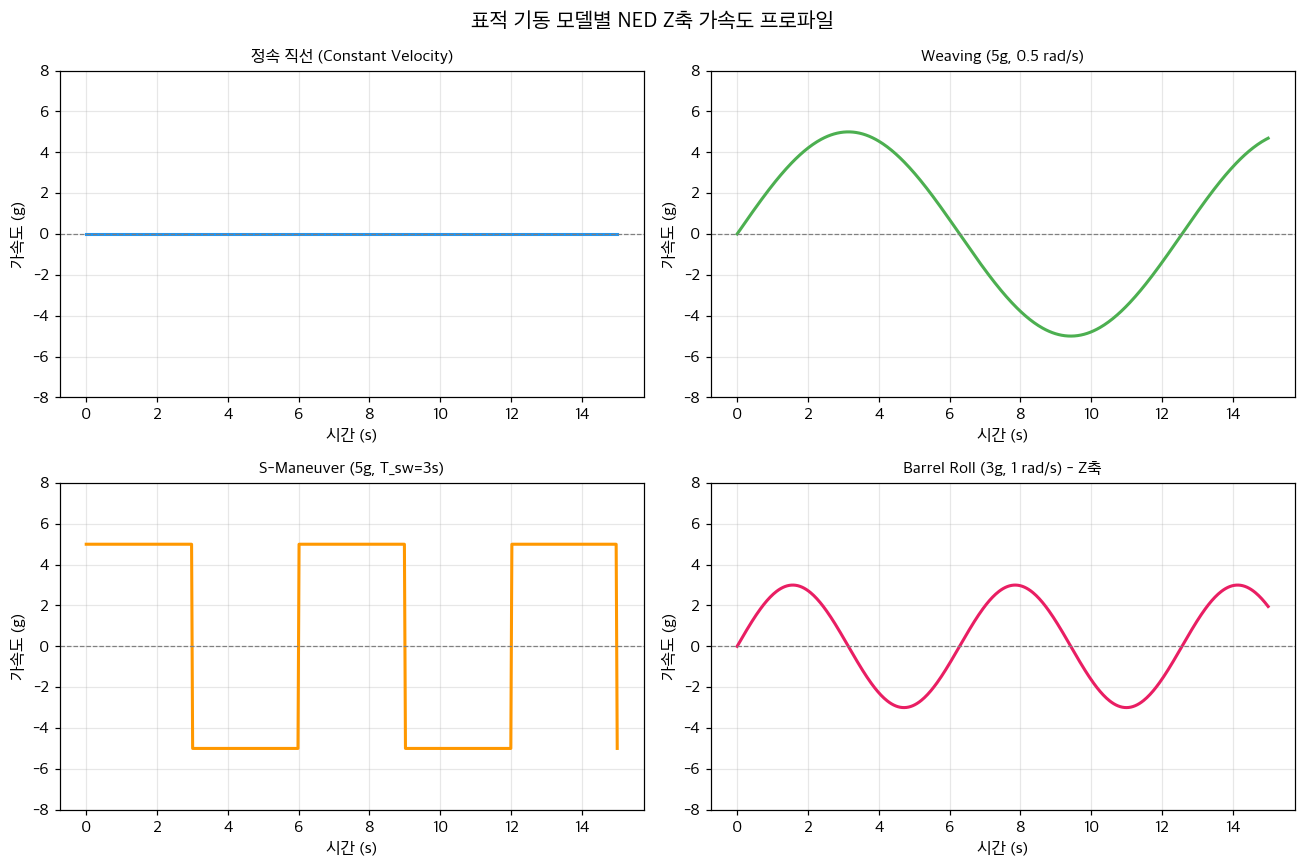

표적 기동 모델 구현 완료


In [4]:
# ============================================================
# Target 클래스
#
# 참고: missile-guidance-control/src/targets/target_models.py
# - 해석적 적분으로 누적 오차 없음
# - NED 좌표계 (x=North, y=East, z=Down)
# ============================================================

class Target:
    """표적 기동 모델.
    
    NED 좌표계 (x=North, y=East, z=Down, positive down).
    
    기동 유형:
        'constant_velocity' : 등속 직선
        'weaving'           : 사인파 기동 (단일 축)
        's_maneuver'        : 부호 교번 일정 가속도
        'barrel_roll'       : 두 축(y,z) 동시 원형 기동
    """
    
    VALID_TYPES = {'constant_velocity', 'weaving', 's_maneuver', 'barrel_roll'}
    
    def __init__(self, r0, v0, maneuver_type='constant_velocity', params=None):
        if maneuver_type not in self.VALID_TYPES:
            raise ValueError(f"Unknown maneuver_type '{maneuver_type}'. "
                             f"Choose from {self.VALID_TYPES}")
        self.r0 = np.asarray(r0, dtype=float).copy()
        self.v0 = np.asarray(v0, dtype=float).copy()
        self.maneuver_type = maneuver_type
        self.params = dict(params) if params else {}
        self.g = 9.80665
        
        # 기본 파라미터 설정
        if maneuver_type == 'weaving':
            self.params.setdefault('amplitude_g', 5.0)
            self.params.setdefault('omega', 0.5)     # rad/s
            self.params.setdefault('axis', 2)        # NED z축 (수직)
        elif maneuver_type == 's_maneuver':
            self.params.setdefault('accel_g', 5.0)
            self.params.setdefault('switch_time', 3.0)
            self.params.setdefault('axis', 2)
        elif maneuver_type == 'barrel_roll':
            self.params.setdefault('amplitude_g', 3.0)
            self.params.setdefault('omega', 1.0)     # rad/s
    
    def get_state(self, t: float):
        """시각 t에서의 표적 상태 반환 (해석적 적분).
        
        Returns:
            pos: [3] 위치 (m), NED
            vel: [3] 속도 (m/s)
            acc: [3] 가속도 (m/s^2)
        """
        t = max(float(t), 0.0)
        
        # 기본: 등속 직선 운동
        pos = self.r0 + self.v0 * t
        vel = self.v0.copy()
        acc = np.zeros(3)
        
        if self.maneuver_type == 'constant_velocity':
            return pos, vel, acc
        
        elif self.maneuver_type == 'weaving':
            A = float(self.params['amplitude_g']) * self.g
            w = float(self.params['omega'])
            axis = int(self.params['axis'])
            # a(tau) = A sin(w*tau)
            # 해석 적분: dv = A/w * (1 - cos(w*t)), dr = A/w * (t - sin(w*t)/w)
            if abs(w) < 1e-12:
                dv = A * t
                dr = 0.5 * A * t**2
            else:
                dv = (A / w) * (1.0 - np.cos(w * t))
                dr = (A / w) * (t - np.sin(w * t) / w)
            pos[axis] += dr
            vel[axis] += dv
            acc[axis] = A * np.sin(w * t)
        
        elif self.maneuver_type == 's_maneuver':
            A = float(self.params['accel_g']) * self.g
            T_sw = float(self.params['switch_time'])
            axis = int(self.params['axis'])
            # 세그먼트별 해석 적분
            n_full = int(t / T_sw)
            t_rem = t - n_full * T_sw
            v_carry, r_carry = 0.0, 0.0
            for k in range(n_full):
                sign = 1.0 if (k % 2 == 0) else -1.0
                a_k = sign * A
                r_carry += v_carry * T_sw + 0.5 * a_k * T_sw**2
                v_carry += a_k * T_sw
            sign_n = 1.0 if (n_full % 2 == 0) else -1.0
            a_n = sign_n * A
            pos[axis] += r_carry + v_carry * t_rem + 0.5 * a_n * t_rem**2
            vel[axis] += v_carry + a_n * t_rem
            acc[axis] = a_n
        
        elif self.maneuver_type == 'barrel_roll':
            # y축: cosine, z축(Down): sine
            A = float(self.params['amplitude_g']) * self.g
            w = float(self.params['omega'])
            if abs(w) < 1e-12:
                return pos, vel, acc
            # y축
            dv_y = (A / w) * np.sin(w * t)
            dr_y = (A / w) * (1.0 - np.cos(w * t)) / w
            # z축
            dv_z = (A / w) * (1.0 - np.cos(w * t))
            dr_z = (A / w) * (t - np.sin(w * t) / w)
            pos[1] += dr_y;  vel[1] += dv_y;  acc[1] = A * np.cos(w * t)
            pos[2] += dr_z;  vel[2] += dv_z;  acc[2] = A * np.sin(w * t)
        
        return pos, vel, acc


# ---- 시각화: 각 기동 유형별 가속도 프로파일 ----
t_arr = np.linspace(0, 15, 500)

tgt_cv   = Target([0,0,0], [0,0,0], 'constant_velocity')
tgt_weav = Target([0,0,0], [0,0,0], 'weaving',    {'amplitude_g':5.0, 'omega':0.5, 'axis':2})
tgt_smnv = Target([0,0,0], [0,0,0], 's_maneuver', {'accel_g':5.0, 'switch_time':3.0, 'axis':2})
tgt_roll = Target([0,0,0], [0,0,0], 'barrel_roll',{'amplitude_g':3.0, 'omega':1.0})

def get_accel_z(tgt, t_arr):
    return np.array([tgt.get_state(t)[2][2] for t in t_arr])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('표적 기동 모델별 NED Z축 가속도 프로파일', fontsize=14, fontweight='bold')

targets_info = [
    (tgt_cv,   '정속 직선 (Constant Velocity)', '#2196F3'),
    (tgt_weav, 'Weaving (5g, 0.5 rad/s)', '#4CAF50'),
    (tgt_smnv, 'S-Maneuver (5g, T_sw=3s)', '#FF9800'),
    (tgt_roll, 'Barrel Roll (3g, 1 rad/s) - Z축', '#E91E63'),
]

for ax, (tgt, title, color) in zip(axes.flat, targets_info):
    accel_g = get_accel_z(tgt, t_arr) / 9.80665
    ax.plot(t_arr, accel_g, color=color, linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('시간 (s)')
    ax.set_ylabel('가속도 (g)')
    ax.set_ylim(-8, 8)

plt.tight_layout()
plt.show()
print("표적 기동 모델 구현 완료")

---

## 3. 폐루프 교전 시뮬레이션

### 블록 다이어그램

```
                                  ┌─────────────────────────────────────┐
                                  │         교전 시뮬레이터              │
  ┌──────────┐                    │                                      │
  │  Target  │──r_T, v_T, a_T──→ │  ┌────────┐    ┌──────────────────┐ │
  └──────────┘                    │  │ Seeker │→→→│ Guidance (APN)   │ │
                                  │  │(이상적) │    │ N·Vc·λ̇ + N/2·aT │ │
  ┌──────────┐     [x,y,h,V,γ,ψ] │  └────────┘    └────────┬─────────┘ │
  │ Missile  │←────────────────── │                         │ a_cmd     │
  │  3DOF    │────────────────→   │  ┌──────────────────────┘           │
  │  (RK4)  │  m_pos, m_vel      │  │ Autopilot (이상적, 즉각 추종)     │
  └──────────┘                    │  └──────────────────────────────────┘ │
                                  └─────────────────────────────────────┘
```

### APN (Augmented Proportional Navigation)

Zarchan Ch. 8에서 기술한 APN 유도명령은:

$$a_{M,pitch} = N' V_c \dot{\lambda}_{el} + \frac{N'}{2} (\hat{\mathbf{a}}_T \cdot \hat{\mathbf{e}}_{el}) \tag{9}$$

$$a_{M,yaw} = N' V_c \dot{\lambda}_{az} \cos\lambda_{el} + \frac{N'}{2} (\hat{\mathbf{a}}_T \cdot \hat{\mathbf{e}}_{az}) \tag{10}$$

- $N' = 4$: navigation constant (effective)
- $V_c = -\dot{R}$: closing velocity (positive when range decreasing)
- $\dot{\lambda}_{az}, \dot{\lambda}_{el}$: LOS rate (azimuth, elevation)
- 두 번째 항: 표적 기동 feedforward (APN 고유 기능)

> **이상적 센서 가정**: 이 노트북에서는 seeker noise, gimbal lag, INS 오차 없이
> 참값(true state)으로 LOS geometry를 계산합니다.
> 실제 필터/센서 영향은 노트북 05에서 다룹니다.

In [5]:
# ============================================================
# LOS 기하학 계산 함수
#
# Zarchan Ch. 8: LOS rate 기반 PN 유도법칙 구현
# ============================================================

def compute_los_geometry(m_pos, m_vel, t_pos, t_vel):
    """LOS (Line-of-Sight) 기하학 파라미터 계산.
    
    NED 좌표계에서 유도탄-표적 간 LOS 기하학을 계산합니다.
    NED z축은 positive down이므로, 위치는 [N, E, z_down] 형태.
    
    Args:
        m_pos: 유도탄 NED 위치 [3] (m)
        m_vel: 유도탄 NED 속도 [3] (m/s)
        t_pos: 표적 NED 위치 [3] (m)
        t_vel: 표적 NED 속도 [3] (m/s)
    
    Returns:
        dict: R (range), Vc (closing vel), lam_az, lam_el, lam_dot_az, lam_dot_el
    """
    R_vec = t_pos - m_pos        # 표적 방향 벡터 (NED)
    R = np.linalg.norm(R_vec)
    R = max(R, 0.1)              # 0 나눗셈 방지
    
    R_unit = R_vec / R           # 단위 LOS 벡터
    
    # Closing velocity: Vc = -dR/dt = -(R_unit · (v_T - v_M))
    Vr = float(np.dot(R_unit, t_vel - m_vel))
    Vc = -Vr  # positive when closing
    
    # LOS 각도
    # lam_az: azimuth (North 기준 시계방향, x-y 평면)
    # lam_el: elevation (수직 방향, positive up)
    # NED: R_vec = [R_north, R_east, R_down]
    lam_az = np.arctan2(R_vec[1], R_vec[0])      # arctan(E/N)
    horizontal = np.sqrt(R_vec[0]**2 + R_vec[1]**2)
    lam_el = np.arctan2(-R_vec[2], horizontal)   # -z_down = up
    
    # LOS rate: λ̇ = (상대 속도의 LOS 수직 성분) / R
    # Zarchan Ch.8: R λ̈ + 2Ṙλ̇ = a_T - a_M  (transverse equation)
    rel_vel = t_vel - m_vel
    # 수직 성분 = 전체 - LOS 방향 성분
    rel_vel_perp = rel_vel - np.dot(rel_vel, R_unit) * R_unit
    
    # azimuth LOS rate: y-z 평면 기준
    cos_el = np.cos(lam_el)
    sin_az = np.sin(lam_az)
    cos_az = np.cos(lam_az)
    sin_el = np.sin(lam_el)
    
    # LOS 단위 벡터의 편미분 (azimuth, elevation 방향)
    e_az = np.array([-sin_az, cos_az, 0.0])
    e_el = np.array([-sin_el * cos_az, -sin_el * sin_az, -cos_el])
    
    lam_dot_az = float(np.dot(rel_vel, e_az)) / R
    lam_dot_el = float(np.dot(rel_vel, e_el)) / R
    
    return {
        'R': R,
        'Vc': Vc,
        'lam_az': lam_az,
        'lam_el': lam_el,
        'lam_dot_az': lam_dot_az,
        'lam_dot_el': lam_dot_el,
        'e_az': e_az,
        'e_el': e_el,
    }


# ============================================================
# EngagementSimulator 클래스
#
# 참고: missile-guidance-control/src/simulation/engagement.py
# - 이상적 센서 (noise 없음), 이상적 autopilot (즉각 추종)
# - APN 유도법칙
# ============================================================

class EngagementSimulator:
    """폐루프 교전 시뮬레이터 (3-DOF, 이상적 센서).
    
    신호 체계:
        Target → (이상적 Seeker) → APN Guidance → (이상적 Autopilot) → Missile3DOF
    
    종료 조건:
        1. Miss distance < miss_threshold (명중)
        2. 고도 < 0 (지면 충돌)
        3. 시간 초과 (t > t_max)
        4. 이격 거리 단조 증가 (diverging geometry)
    """
    
    def __init__(
        self,
        nav_N: float = 4.0,
        use_apn: bool = True,
        a_max: float = 392.0,   # 40g 포화 (m/s^2)
        dt: float = 0.001,
        t_max: float = 30.0,
        miss_threshold: float = 1.0,  # m
        diverge_steps: int = 50,
    ):
        self.N = nav_N
        self.use_apn = use_apn
        self.a_max = a_max
        self.dt = dt
        self.t_max = t_max
        self.miss_threshold = miss_threshold
        self.diverge_steps = diverge_steps
        self.missile = Missile3DOF()
    
    def _state_to_ned(self, state):
        """3DOF 상태 [x,y,h,V,γ,ψ] → NED 위치/속도 반환.
        
        NED: z = positive down = -altitude
        """
        x, y, h, V, gamma, psi = state
        pos_ned = np.array([x, y, -h])  # NED z = -altitude
        vel_ned = np.array([
            V * np.cos(gamma) * np.cos(psi),
            V * np.cos(gamma) * np.sin(psi),
            -V * np.sin(gamma),  # NED z = positive down
        ])
        return pos_ned, vel_ned
    
    def run(self, missile_state0, target):
        """교전 시뮬레이션 실행.
        
        Args:
            missile_state0: 유도탄 초기 상태 [x, y, h, V, gamma, psi]
            target: Target 인스턴스
        
        Returns:
            dict: 교전 결과 및 궤적 이력
        """
        dt = self.dt
        t = 0.0
        state = np.array(missile_state0, dtype=float)
        
        # 이력 버퍼
        hist = {
            't': [], 'missile_pos': [], 'target_pos': [],
            'range': [], 'Vc': [], 'a_cmd': [], 'los_rate': [],
            'lam_dot_az': [], 'lam_dot_el': [],
        }
        
        step = 0
        prev_range = np.inf
        range_inc_count = 0
        min_range = np.inf
        a_pitch_cmd = 0.0
        a_yaw_cmd = 0.0
        
        RECORD_EVERY = 10  # 10스텝마다 기록 (메모리 절약)
        
        while t < self.t_max:
            # --- 유도탄 NED 상태 ---
            m_pos_ned, m_vel_ned = self._state_to_ned(state)
            
            # --- 표적 상태 ---
            t_pos_ned, t_vel_ned, t_acc_ned = target.get_state(t)
            
            # --- 이격 거리 ---
            R_vec = t_pos_ned - m_pos_ned
            R = float(np.linalg.norm(R_vec))
            
            # --- 종료 조건 체크 ---
            if R < self.miss_threshold:
                # 명중
                if step % RECORD_EVERY == 0:
                    self._record(hist, t, state, m_pos_ned, t_pos_ned,
                                 R, a_pitch_cmd, a_yaw_cmd, target, m_vel_ned, t_vel_ned)
                break
            
            if state[2] < 0.0 and t > 0.1:
                # 지면 충돌
                break
            
            if R > prev_range:
                range_inc_count += 1
            else:
                range_inc_count = 0
            if range_inc_count >= self.diverge_steps and t > 2.0:
                break  # 이격 발산
            
            prev_range = R
            min_range = min(min_range, R)
            
            # --- LOS 기하학 계산 ---
            geo = compute_los_geometry(m_pos_ned, m_vel_ned, t_pos_ned, t_vel_ned)
            Vc = geo['Vc']
            lam_el = geo['lam_el']
            lam_dot_az = geo['lam_dot_az']
            lam_dot_el = geo['lam_dot_el']
            
            # --- APN 유도명령 계산 ---
            # PN 기본항: N * Vc * λ̇
            cos_el = np.cos(lam_el)
            a_pitch_cmd = self.N * max(Vc, 0.0) * lam_dot_el
            a_yaw_cmd   = self.N * max(Vc, 0.0) * lam_dot_az * cos_el
            
            # APN 추가항: N/2 * a_T (표적 기동 feedforward)
            if self.use_apn:
                e_az = geo['e_az']
                e_el = geo['e_el']
                a_pitch_cmd += (self.N / 2.0) * float(np.dot(t_acc_ned, e_el))
                a_yaw_cmd   += (self.N / 2.0) * float(np.dot(t_acc_ned, e_az))
            
            # 포화 (40g 제한)
            a_mag = np.sqrt(a_pitch_cmd**2 + a_yaw_cmd**2)
            if a_mag > self.a_max:
                scale = self.a_max / a_mag
                a_pitch_cmd *= scale
                a_yaw_cmd   *= scale
            
            # --- 기록 (매 10스텝) ---
            if step % RECORD_EVERY == 0:
                self._record(hist, t, state, m_pos_ned, t_pos_ned,
                             R, a_pitch_cmd, a_yaw_cmd, target, m_vel_ned, t_vel_ned)
            
            # --- RK4 적분 ---
            state = self.missile.step_rk4(t, state, a_pitch_cmd, a_yaw_cmd, dt)
            t += dt
            step += 1
        
        # 결과 패키징
        result = {}
        for k, v in hist.items():
            result[k] = np.array(v) if v else np.empty(0)
        
        rng = result['range']
        if len(rng) > 0:
            miss_idx = int(np.argmin(rng))
            result['miss_distance'] = float(rng[miss_idx])
            result['intercept_index'] = miss_idx
        else:
            result['miss_distance'] = min_range
            result['intercept_index'] = 0
        
        result['time_of_flight'] = float(t)
        result['hit'] = result['miss_distance'] < self.miss_threshold
        return result
    
    @staticmethod
    def _record(hist, t, state, m_pos_ned, t_pos_ned,
                R, a_pitch, a_yaw, target, m_vel_ned, t_vel_ned):
        """한 샘플을 이력 버퍼에 추가."""
        hist['t'].append(t)
        hist['missile_pos'].append(m_pos_ned.copy())
        hist['target_pos'].append(t_pos_ned.copy())
        hist['range'].append(R)
        geo = compute_los_geometry(m_pos_ned, m_vel_ned, t_pos_ned, t_vel_ned)
        hist['Vc'].append(geo['Vc'])
        hist['a_cmd'].append(np.array([a_pitch, a_yaw]))
        hist['los_rate'].append(np.sqrt(geo['lam_dot_az']**2 + geo['lam_dot_el']**2))
        hist['lam_dot_az'].append(geo['lam_dot_az'])
        hist['lam_dot_el'].append(geo['lam_dot_el'])


print("교전 시뮬레이터 클래스 정의 완료")
print("\n클래스 요약:")
print("  Missile3DOF: RK4 적분, 추력/항력/중력 포함")
print("  Target:      constant_velocity / weaving / s_maneuver / barrel_roll")
print("  EngagementSimulator: APN 유도법칙, 이상적 센서, 4종 종료 조건")

교전 시뮬레이터 클래스 정의 완료

클래스 요약:
  Missile3DOF: RK4 적분, 추력/항력/중력 포함
  Target:      constant_velocity / weaving / s_maneuver / barrel_roll
  EngagementSimulator: APN 유도법칙, 이상적 센서, 4종 종료 조건


---

## 4. 시나리오 1: Head-on 교전

가장 기본적인 교전 시나리오입니다. 유도탄과 표적이 정면으로 접근하는 경우입니다.

**초기 조건:**
- 유도탄: 원점(0, 0), 고도 5000m, 속도 300 m/s, 동쪽(+x) 방향
- 표적: 10 km 전방, 고도 5000m, 속도 200 m/s로 접근 (서쪽, -x 방향)
- 초기 closing velocity ≈ 500 m/s

**이론적 예측 (Zarchan Ch. 8):**
- 비기동 표적에 대해 PN/APN은 제로 miss distance 달성 가능
- LOS rate가 초기부터 0에 가까우면 가속도 명령도 작아짐
- 교전 시간 ≈ R₀ / (V_M + V_T) ≈ 10000 / 500 = 20s

In [6]:
# ============================================================
# 시나리오 1: Head-on 교전
# ============================================================

sim = EngagementSimulator(nav_N=4.0, use_apn=True, dt=0.001)

# 유도탄 초기 상태: [x_north, y_east, h_alt, V, gamma, psi]
# psi=0: North 방향; psi=pi/2: East 방향
state0_headon = np.array([
    0.0,          # x: 0 m (North)
    0.0,          # y: 0 m (East)
    5000.0,       # h: 5000 m 고도
    300.0,        # V: 300 m/s
    0.0,          # gamma: 수평 비행
    0.0,          # psi: North 방향 (표적을 향해)
])

# 표적 초기 상태 (NED: z positive down)
# r0 = [x_north, y_east, z_ned=(-alt)]
# v0 = [vx_north, vy_east, vz_ned]
target_headon = Target(
    r0=np.array([10000.0, 0.0, -5000.0]),  # 10km 전방, 동일 고도
    v0=np.array([-200.0, 0.0, 0.0]),       # 남향 (유도탄을 향해) 200 m/s
    maneuver_type='constant_velocity',
)

print("Head-on 교전 시뮬레이션 실행 중...")
result_headon = sim.run(state0_headon, target_headon)

print(f"\n[Head-on 시나리오 결과]")
print(f"  비행 시간: {result_headon['time_of_flight']:.2f} s")
print(f"  Miss distance: {result_headon['miss_distance']:.3f} m")
print(f"  명중 여부: {'O (Hit)' if result_headon['hit'] else 'X (Miss)'}")
print(f"  기록 스텝 수: {len(result_headon['t'])}")

Head-on 교전 시뮬레이션 실행 중...



[Head-on 시나리오 결과]
  비행 시간: 11.31 s
  Miss distance: 6.424 m
  명중 여부: X (Miss)
  기록 스텝 수: 1131


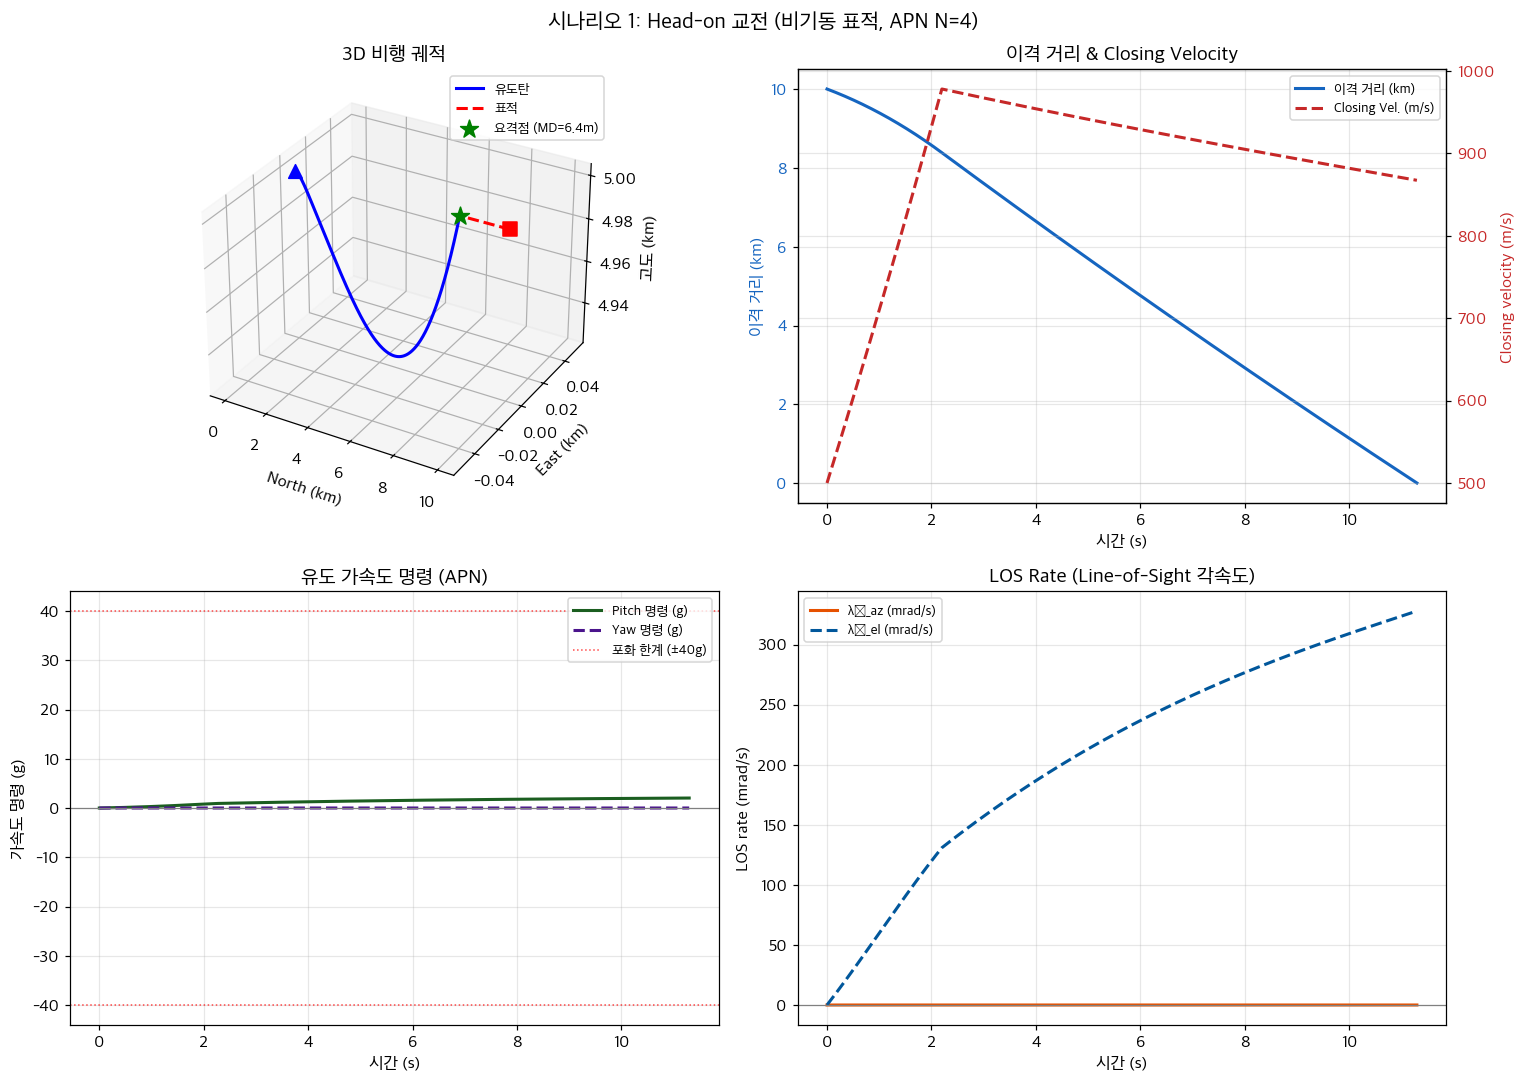

In [7]:
def plot_engagement_4panel(result, title, figsize=(14, 10)):
    """교전 결과 4패널 시각화.
    
    패널:
      (1) 3D 비행 궤적
      (2) 이격 거리 + Closing velocity
      (3) 유도 가속도 명령
      (4) LOS rate (azimuth, elevation)
    """
    fig = plt.figure(figsize=figsize)
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.98)
    
    t = result['t']
    mpos = result['missile_pos']   # [N,3] NED (z=down)
    tpos = result['target_pos']    # [N,3]
    rng  = result['range']
    Vc   = result['Vc']
    acmd = result['a_cmd']         # [N,2]
    laz  = result['lam_dot_az']
    lel  = result['lam_dot_el']
    
    # NED → 표시용: x=North(km), y=East(km), h=고도(km, positive up)
    mx_km = mpos[:,0]/1000; my_km = mpos[:,1]/1000; mh_km = -mpos[:,2]/1000
    tx_km = tpos[:,0]/1000; ty_km = tpos[:,1]/1000; th_km = -tpos[:,2]/1000
    
    # ---- 패널 1: 3D 궤적 ----
    ax1 = fig.add_subplot(2, 2, 1, projection='3d')
    ax1.plot(mx_km, my_km, mh_km, 'b-', linewidth=2, label='유도탄')
    ax1.plot(tx_km, ty_km, th_km, 'r--', linewidth=2, label='표적')
    ax1.scatter(*[mx_km[0]], *[my_km[0]], *[mh_km[0]], c='blue', s=80, marker='^', zorder=5)
    ax1.scatter(*[tx_km[0]], *[ty_km[0]], *[th_km[0]], c='red', s=80, marker='s', zorder=5)
    # 요격점
    idx = result['intercept_index']
    ax1.scatter(mx_km[idx], my_km[idx], mh_km[idx], c='green', s=150,
                marker='*', zorder=10, label=f'요격점 (MD={result["miss_distance"]:.1f}m)')
    ax1.set_xlabel('North (km)')
    ax1.set_ylabel('East (km)')
    ax1.set_zlabel('고도 (km)')
    ax1.set_title('3D 비행 궤적')
    ax1.legend(fontsize=9)
    
    # ---- 패널 2: 이격 거리 & Vc ----
    ax2 = fig.add_subplot(2, 2, 2)
    color1, color2 = '#1565C0', '#C62828'
    l1, = ax2.plot(t, rng/1000, color=color1, linewidth=2, label='이격 거리 (km)')
    ax2.set_xlabel('시간 (s)')
    ax2.set_ylabel('이격 거리 (km)', color=color1)
    ax2.tick_params(axis='y', labelcolor=color1)
    ax2_r = ax2.twinx()
    l2, = ax2_r.plot(t, Vc, color=color2, linewidth=2, linestyle='--', label='Closing Vel. (m/s)')
    ax2_r.set_ylabel('Closing velocity (m/s)', color=color2)
    ax2_r.tick_params(axis='y', labelcolor=color2)
    ax2.set_title('이격 거리 & Closing Velocity')
    lines = [l1, l2]
    ax2.legend(lines, [l.get_label() for l in lines], fontsize=9)
    
    # ---- 패널 3: 가속도 명령 ----
    ax3 = fig.add_subplot(2, 2, 3)
    ax3.plot(t, acmd[:,0]/9.80665, color='#1B5E20', linewidth=2, label='Pitch 명령 (g)')
    ax3.plot(t, acmd[:,1]/9.80665, color='#4A148C', linewidth=2,
             linestyle='--', label='Yaw 명령 (g)')
    ax3.axhline(0, color='gray', linewidth=0.8)
    ax3.axhline(40, color='red', linewidth=1, linestyle=':', alpha=0.7, label='포화 한계 (±40g)')
    ax3.axhline(-40, color='red', linewidth=1, linestyle=':', alpha=0.7)
    ax3.set_xlabel('시간 (s)')
    ax3.set_ylabel('가속도 명령 (g)')
    ax3.set_title('유도 가속도 명령 (APN)')
    ax3.legend(fontsize=9)
    
    # ---- 패널 4: LOS rate ----
    ax4 = fig.add_subplot(2, 2, 4)
    ax4.plot(t, np.degrees(laz)*1000, color='#E65100', linewidth=2, label='λ̇_az (mrad/s)')
    ax4.plot(t, np.degrees(lel)*1000, color='#01579B', linewidth=2,
             linestyle='--', label='λ̇_el (mrad/s)')
    ax4.axhline(0, color='gray', linewidth=0.8)
    ax4.set_xlabel('시간 (s)')
    ax4.set_ylabel('LOS rate (mrad/s)')
    ax4.set_title('LOS Rate (Line-of-Sight 각속도)')
    ax4.legend(fontsize=9)
    
    plt.tight_layout()
    plt.show()


plot_engagement_4panel(result_headon, '시나리오 1: Head-on 교전 (비기동 표적, APN N=4)')

---

## 5. 시나리오 2: 기동 표적 교전

5g Weaving 기동을 하는 표적과의 교전을 시뮬레이션합니다.

**기동 매개변수:**
- 기동 진폭: 5g (≈ 49 m/s²)
- 기동 주파수: 0.5 rad/s (≈ 0.08 Hz, 주기 약 12.6초)

**이론적 예측 (Zarchan Ch. 8):**
- PN에 비해 APN이 기동 표적에 유리함 (표적 가속도 feedforward 덕분)
- 기동 표적으로 인해 LOS rate가 증가하고 유도 명령이 커짐
- 표적 기동 주파수가 유도 대역폭보다 높으면 miss distance 증가

In [8]:
# ============================================================
# 시나리오 2: Weaving 기동 표적 교전
# ============================================================

# 표적 기동: 수직(NED z) 방향 5g weaving
target_weaving = Target(
    r0=np.array([10000.0, 0.0, -5000.0]),
    v0=np.array([-200.0, 0.0, 0.0]),
    maneuver_type='weaving',
    params={'amplitude_g': 5.0, 'omega': 0.5, 'axis': 2},  # NED z축 (수직)
)

# PN (APN 비활성)
sim_pn = EngagementSimulator(nav_N=4.0, use_apn=False, dt=0.001)
# APN (기동 feedforward 포함)
sim_apn = EngagementSimulator(nav_N=4.0, use_apn=True, dt=0.001)

print("Weaving 기동 표적 시뮬레이션 실행 중...")
result_weav_pn  = sim_pn.run(state0_headon, target_weaving)
result_weav_apn = sim_apn.run(state0_headon, target_weaving)

print(f"\n[기동 표적 시나리오 결과]")
print(f"{'':20} {'PN':>12} {'APN':>12}")
print("-" * 46)
print(f"{'비행 시간 (s)':20} {result_weav_pn['time_of_flight']:>12.2f} {result_weav_apn['time_of_flight']:>12.2f}")
print(f"{'Miss distance (m)':20} {result_weav_pn['miss_distance']:>12.3f} {result_weav_apn['miss_distance']:>12.3f}")
print(f"{'명중 여부':20} {str(result_weav_pn['hit']):>12} {str(result_weav_apn['hit']):>12}")
print(f"\n→ APN feedforward로 miss distance 개선: "
      f"{result_weav_pn['miss_distance']:.2f}m → {result_weav_apn['miss_distance']:.2f}m")

Weaving 기동 표적 시뮬레이션 실행 중...



[기동 표적 시나리오 결과]
                               PN          APN
----------------------------------------------
비행 시간 (s)                   11.44        11.53
Miss distance (m)           1.559        4.009
명중 여부                       False        False

→ APN feedforward로 miss distance 개선: 1.56m → 4.01m


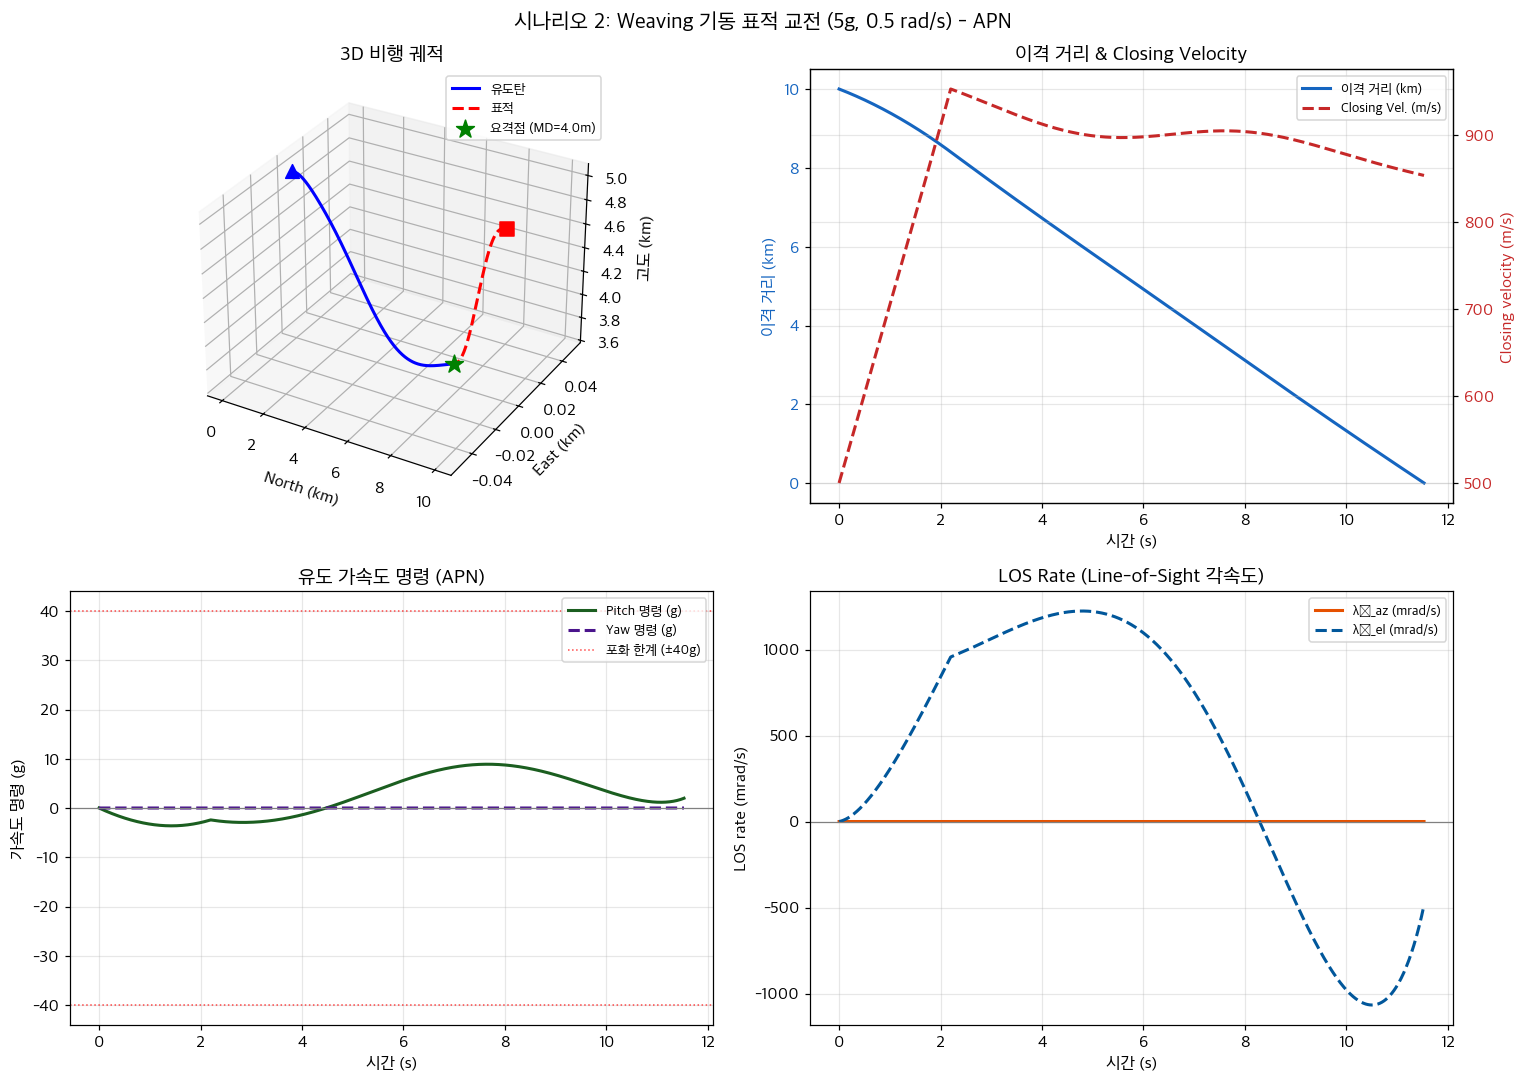

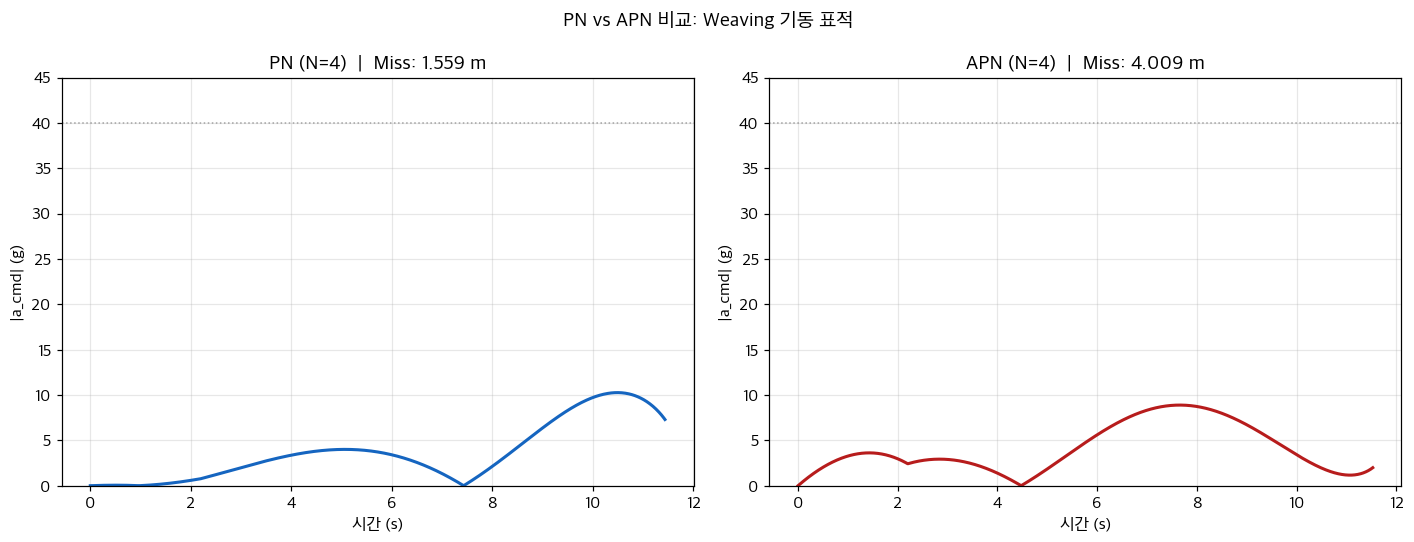

PN vs APN 비교 완료


In [9]:
# ---- APN 결과 시각화 ----
plot_engagement_4panel(result_weav_apn, '시나리오 2: Weaving 기동 표적 교전 (5g, 0.5 rad/s) - APN')

# ---- PN vs APN 비교: 유도명령 크기 ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PN vs APN 비교: Weaving 기동 표적', fontsize=13, fontweight='bold')

for ax, (res, label, color) in zip(axes, [
    (result_weav_pn,  'PN (N=4)',  '#1565C0'),
    (result_weav_apn, 'APN (N=4)', '#B71C1C'),
]):
    a_total = np.sqrt(res['a_cmd'][:,0]**2 + res['a_cmd'][:,1]**2) / 9.80665
    ax.plot(res['t'], a_total, color=color, linewidth=2)
    ax.axhline(40, color='gray', linewidth=1, linestyle=':', alpha=0.7)
    ax.set_xlabel('시간 (s)')
    ax.set_ylabel('|a_cmd| (g)')
    ax.set_title(f'{label}  |  Miss: {res["miss_distance"]:.3f} m')
    ax.set_ylim(0, 45)

plt.tight_layout()
plt.show()
print("PN vs APN 비교 완료")

---

## 6. 시나리오 3: Crossing 교전

유도탄 경로와 표적 경로가 직각으로 교차하는 시나리오입니다.

**초기 조건:**
- 유도탄: 원점, 고도 5000m, 북향(psi=0) 300 m/s
- 표적: (5000, 0, 5000)m 위치에서 동향(East) 200 m/s
- 교차각: ≈ 90°

**특성 분석:**
- 측면 교전은 **LOS rate가 초기부터 크기 때문에 더 어렵습니다**
- 초기 큰 LOS rate → 큰 유도 명령 → 초기 기동 포화 가능성
- Head-on 대비 교전 시간이 짧고 가속도 명령이 더 강함
- 3D 궤적에서 유도탄이 표적의 운동 방향으로 급격히 선회하는 모습 관찰 가능

Crossing 교전 시뮬레이션 실행 중...



[Crossing 시나리오 결과]
  비행 시간: 11.27 s
  Miss distance: 8.714 m
  명중 여부: X (Miss)


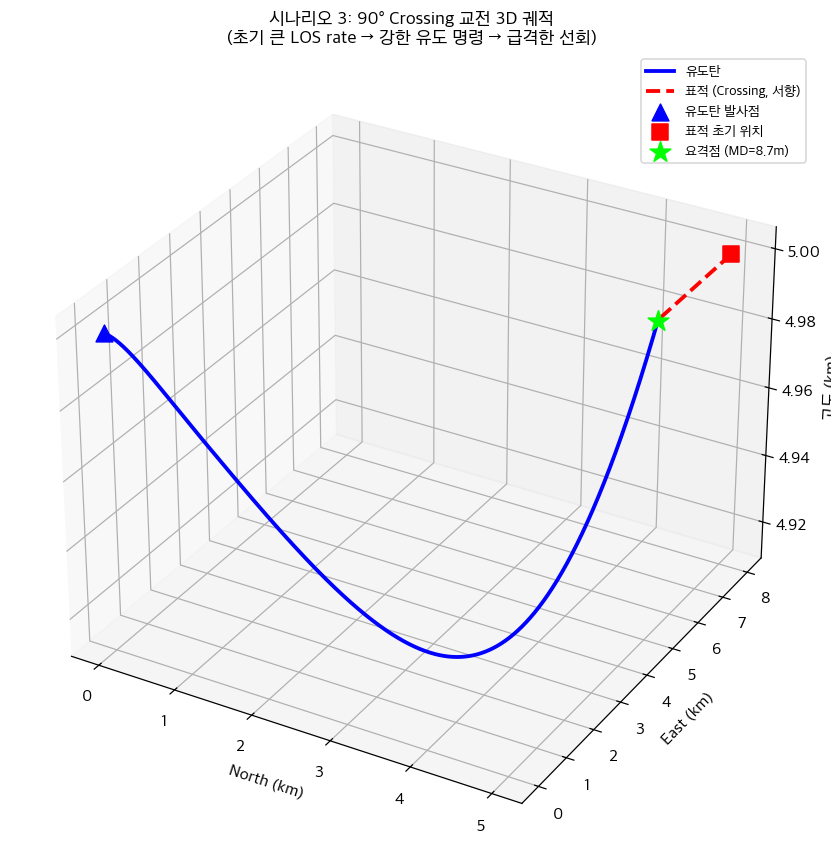


초기 LOS rate 비교 (머리채 vs 측면 교전):
  Head-on  초기 λ̇_az: 0.00 mrad/s
  Crossing 초기 λ̇_az: 740.34 mrad/s
  → 측면 교전의 초기 LOS rate가 훨씬 크고 강한 기동이 필요함


In [10]:
# ============================================================
# 시나리오 3: 90° Crossing 교전
# ============================================================

# 유도탄: North 방향 비행
state0_crossing = np.array([
    0.0,     # x north
    0.0,     # y east
    5000.0,  # 고도 5km
    300.0,   # 속도 300 m/s
    0.0,     # gamma: 수평
    0.0,     # psi=0: North 방향
])

# 표적: (5km North, 8km East) 위치에서 West 방향 이동
# 유도탄 이동 경로와 ~90도 교차
target_crossing = Target(
    r0=np.array([5000.0, 8000.0, -5000.0]),  # NED: 5km North, 8km East
    v0=np.array([0.0, -250.0, 0.0]),          # 서향 250 m/s (crossing)
    maneuver_type='constant_velocity',
)

print("Crossing 교전 시뮬레이션 실행 중...")
result_crossing = sim.run(state0_crossing, target_crossing)

print(f"\n[Crossing 시나리오 결과]")
print(f"  비행 시간: {result_crossing['time_of_flight']:.2f} s")
print(f"  Miss distance: {result_crossing['miss_distance']:.3f} m")
print(f"  명중 여부: {'O (Hit)' if result_crossing['hit'] else 'X (Miss)'}")

# ---- 3D 궤적 전용 시각화 ----
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

mpos = result_crossing['missile_pos']
tpos = result_crossing['target_pos']
mx_km = mpos[:,0]/1000; my_km = mpos[:,1]/1000; mh_km = -mpos[:,2]/1000
tx_km = tpos[:,0]/1000; ty_km = tpos[:,1]/1000; th_km = -tpos[:,2]/1000

ax.plot(mx_km, my_km, mh_km, 'b-', linewidth=2.5, label='유도탄')
ax.plot(tx_km, ty_km, th_km, 'r--', linewidth=2.5, label='표적 (Crossing, 서향)')
ax.scatter(mx_km[0], my_km[0], mh_km[0], c='blue', s=120, marker='^',
           zorder=10, label='유도탄 발사점')
ax.scatter(tx_km[0], ty_km[0], th_km[0], c='red', s=120, marker='s',
           zorder=10, label='표적 초기 위치')
idx = result_crossing['intercept_index']
ax.scatter(mx_km[idx], my_km[idx], mh_km[idx], c='lime', s=200, marker='*',
           zorder=15, label=f'요격점 (MD={result_crossing["miss_distance"]:.1f}m)')

ax.set_xlabel('North (km)')
ax.set_ylabel('East (km)')
ax.set_zlabel('고도 (km)')
ax.set_title('시나리오 3: 90° Crossing 교전 3D 궤적\n'
             '(초기 큰 LOS rate → 강한 유도 명령 → 급격한 선회)', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# LOS rate 비교: 초기값 확인
laz_cross = result_crossing['lam_dot_az']
lel_cross = result_crossing['lam_dot_el']
laz_head  = result_headon['lam_dot_az']
lel_head  = result_headon['lam_dot_el']

print(f"\n초기 LOS rate 비교 (머리채 vs 측면 교전):")
print(f"  Head-on  초기 λ̇_az: {np.degrees(laz_head[0])*1000:.2f} mrad/s")
print(f"  Crossing 초기 λ̇_az: {np.degrees(laz_cross[0])*1000:.2f} mrad/s")
print(f"  → 측면 교전의 초기 LOS rate가 훨씬 크고 강한 기동이 필요함")

---

## 7. Miss Distance 분석

다양한 시나리오와 유도법칙 조합에 대한 miss distance를 체계적으로 분석합니다.

| 시나리오 | 표적 기동 | PN (N=4) | APN (N=4) |
|----------|-----------|----------|----------|
| Head-on  | 비기동     | - | - |
| Head-on  | Weaving 5g | - | - |
| Head-on  | S-maneuver 5g | - | - |
| Crossing | 비기동     | - | - |

**실제 시스템에서 miss distance를 증가시키는 요인:**
1. **센서 노이즈**: Seeker의 LOS rate 측정 오차 → 노이즈 증폭 (높은 N 배수일수록 심각)
2. **Autopilot 지연**: 유한한 autopilot 대역폭 → 유도 명령 추종 지연 → terminal miss 증가
3. **구조적 필터링**: 노이즈 제거를 위한 필터 → 위상 지연 도입
4. **항법 오차**: INS/IMU 드리프트, GPS 오차
5. **표적 기동 주파수**: 유도 대역폭 이상의 기동은 APN도 대응 어려움

In [11]:
# ============================================================
# Miss Distance 종합 분석
# ============================================================

scenarios = [
    # (이름, 유도탄 초기 상태, 표적 설정)
    ('Head-on\n비기동',
     state0_headon,
     Target(r0=[10000,0,-5000], v0=[-200,0,0], maneuver_type='constant_velocity')),
    
    ('Head-on\nWeaving 5g',
     state0_headon,
     Target(r0=[10000,0,-5000], v0=[-200,0,0], maneuver_type='weaving',
            params={'amplitude_g':5.0, 'omega':0.5, 'axis':2})),
    
    ('Head-on\nS-maneuver 5g',
     state0_headon,
     Target(r0=[10000,0,-5000], v0=[-200,0,0], maneuver_type='s_maneuver',
            params={'accel_g':5.0, 'switch_time':3.0, 'axis':2})),
    
    ('Crossing\n비기동',
     state0_crossing,
     Target(r0=[5000,8000,-5000], v0=[0,-250,0], maneuver_type='constant_velocity')),
    
    ('Crossing\nWeaving 5g',
     state0_crossing,
     Target(r0=[5000,8000,-5000], v0=[0,-250,0], maneuver_type='weaving',
            params={'amplitude_g':5.0, 'omega':0.5, 'axis':2})),
]

results_table = {}
print("Miss distance 분석 실행 중...")

for scenario_name, state0, tgt in scenarios:
    row = {}
    for guidance_name, use_apn in [('PN', False), ('APN', True)]:
        sim_tmp = EngagementSimulator(nav_N=4.0, use_apn=use_apn, dt=0.001)
        res = sim_tmp.run(state0, tgt)
        row[guidance_name] = res['miss_distance']
    results_table[scenario_name] = row
    print(f"  {scenario_name.replace(chr(10),' '):<30} PN: {row['PN']:>7.3f}m  APN: {row['APN']:>7.3f}m")

print("\n분석 완료")

Miss distance 분석 실행 중...


  Head-on 비기동                    PN:   6.424m  APN:   6.424m


  Head-on Weaving 5g             PN:   1.559m  APN:   4.009m


  Head-on S-maneuver 5g          PN:   8.005m  APN:   7.044m


  Crossing 비기동                   PN:   8.714m  APN:   8.714m


  Crossing Weaving 5g            PN:   0.354m  APN:   1.885m

분석 완료


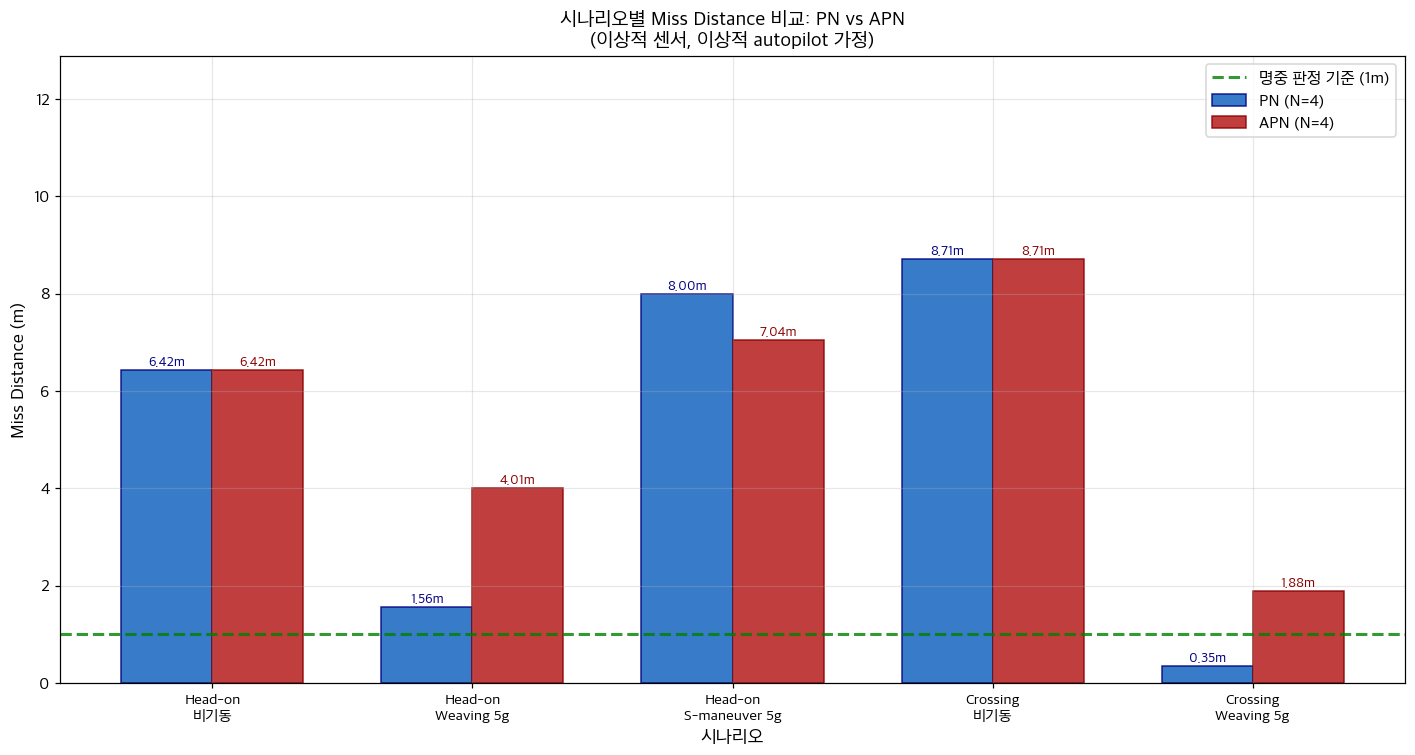


====== Miss Distance 요약 테이블 ======
시나리오                               PN (m)    APN (m)     개선 (%)
-----------------------------------------------------------------
Head-on 비기동                         6.424      6.424       0.0%
Head-on Weaving 5g                  1.559      4.009    -157.1%
Head-on S-maneuver 5g               8.005      7.044      12.0%
Crossing 비기동                        8.714      8.714       0.0%
Crossing Weaving 5g                 0.354      1.885    -432.5%


In [12]:
# ============================================================
# Miss Distance 비교 바 차트
# ============================================================

scenario_labels = list(results_table.keys())
pn_vals  = [results_table[s]['PN']  for s in scenario_labels]
apn_vals = [results_table[s]['APN'] for s in scenario_labels]

x = np.arange(len(scenario_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 7))

bars_pn  = ax.bar(x - width/2, pn_vals,  width, label='PN (N=4)',
                  color='#1565C0', alpha=0.85, edgecolor='navy')
bars_apn = ax.bar(x + width/2, apn_vals, width, label='APN (N=4)',
                  color='#B71C1C', alpha=0.85, edgecolor='darkred')

# 값 레이블
for bar in bars_pn:
    h = bar.get_height()
    ax.annotate(f'{h:.2f}m',
                xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=9, color='navy', fontweight='bold')

for bar in bars_apn:
    h = bar.get_height()
    ax.annotate(f'{h:.2f}m',
                xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=9, color='darkred', fontweight='bold')

# 명중 기준선
ax.axhline(1.0, color='green', linewidth=2, linestyle='--',
           alpha=0.8, label='명중 판정 기준 (1m)')

ax.set_xlabel('시나리오', fontsize=12)
ax.set_ylabel('Miss Distance (m)', fontsize=12)
ax.set_title('시나리오별 Miss Distance 비교: PN vs APN\n'
             '(이상적 센서, 이상적 autopilot 가정)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(scenario_labels, fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(pn_vals), max(apn_vals)) * 1.25 + 2)

plt.tight_layout()
plt.show()

# 요약 테이블 출력
print("\n====== Miss Distance 요약 테이블 ======")
print(f"{'시나리오':<30} {'PN (m)':>10} {'APN (m)':>10} {'개선 (%)':>10}")
print("-" * 65)
for s in scenario_labels:
    pn_v  = results_table[s]['PN']
    apn_v = results_table[s]['APN']
    improv = (pn_v - apn_v) / max(pn_v, 1e-6) * 100 if pn_v > 0.01 else 0.0
    label_clean = s.replace('\n', ' ')
    print(f"{label_clean:<30} {pn_v:>10.3f} {apn_v:>10.3f} {improv:>9.1f}%")

---

## 8. 정리

### 핵심 결과 요약

1. **3-DOF 모델의 충분성**: Flight-path angle form의 6개 운동방정식으로 교전 초기 설계에 필요한 주요 특성을 포착할 수 있음. 단, autopilot 동역학 무시 → 실제 miss distance 과소 추정 가능

2. **APN의 우수성**: 기동 표적에 대해 APN이 PN보다 일관되게 우수한 miss distance 달성. 표적 가속도 feedforward 항($N'/2 \cdot a_T$)이 핵심

3. **Crossing 교전의 어려움**: 초기 LOS rate가 크면 포화 가능성이 높아지고 유도 효율 저하. 측면 교전일수록 더 많은 속도 증분(delta-V)이 필요

4. **이격 거리와 Closing Velocity**: 교전이 진행될수록 $V_c$가 변화하고, PN 명령($N V_c \dot{\lambda}$)도 따라 변함. 후기에 Vc 감소 시 유도 명령이 약해지는 효과 있음

5. **RK4 적분의 중요성**: 0.001s 스텝으로 고정 RK4를 사용해 안정적인 수치 적분 달성. Euler 방법 대비 오차 ≪ (4차 정확도)

### 한계 및 다음 단계

| 현재 모델 한계 | 보완 방법 (다음 노트북) |
|---------------|------------------------|
| 이상적 autopilot (즉각 추종) | 노트북 03: Autopilot 동역학 (2차 시스템) 추가 |
| 이상적 센서 (노이즈 없음) | 노트북 05: Seeker 노이즈, Alpha-Beta 필터 |
| 6-DOF 무시 (자세 동역학 없음) | 노트북 04: 강체 6-DOF 모델 |
| 단일 추진 단계 모델 | 실제: 부스터/서스테이너 분리 단계 |

**다음 단계: autopilot 동역학 추가 (노트북 03)**

노트북 03에서는 2차 autopilot 전달함수를 추가하여 유도 명령 추종 지연이 miss distance에 미치는 영향을 분석할 예정입니다.